<div style="background:linear-gradient(135deg,#0d1117 0%,#161b22 60%,#1c2128 100%);padding:50px 40px;border-radius:16px;border-left:6px solid #c0392b;margin-bottom:20px;">
  <h1 style="color:#ffffff;font-size:2.8em;margin:0;font-weight:900;letter-spacing:-1px;">CRIMINALÍSTICA CATALUÑA</h1>
  <h2 style="color:#e74c3c;font-size:1.4em;margin:10px 0 0 0;font-weight:400;">Análisis Exploratorio de Datos (EDA)</h2>
  <hr style="border:none;border-top:1px solid rgba(255,255,255,0.1);margin:20px 0;">
  <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:15px;">
    <div style="background:rgba(255,255,255,0.05);padding:15px;border-radius:8px;text-align:center;">
      <div style="color:#e74c3c;font-size:1.8em;font-weight:900;">982.882</div>
      <div style="color:#8b949e;font-size:0.85em;">registros en BD</div>
    </div>
    <div style="background:rgba(255,255,255,0.05);padding:15px;border-radius:8px;text-align:center;">
      <div style="color:#3498db;font-size:1.8em;font-weight:900;">2010-2025</div>
      <div style="color:#8b949e;font-size:0.85em;">período analizado</div>
    </div>
    <div style="background:rgba(255,255,255,0.05);padding:15px;border-radius:8px;text-align:center;">
      <div style="color:#2ecc71;font-size:1.8em;font-weight:900;">13</div>
      <div style="color:#8b949e;font-size:0.85em;">tablas MySQL</div>
    </div>
    <div style="background:rgba(255,255,255,0.05);padding:15px;border-radius:8px;text-align:center;">
      <div style="color:#f39c12;font-size:1.8em;font-weight:900;">5</div>
      <div style="color:#8b949e;font-size:0.85em;">fuentes de datos</div>
    </div>
  </div>
  <p style="color:#8b949e;margin:20px 0 0 0;font-size:0.85em;">Proyecto Final · IT Academy Barcelona · 2026 &nbsp;|&nbsp; Fuentes: Mossos d'Esquadra · GUB Barcelona · Ministerio del Interior · Idescat · INE · Open Data Barcelona</p>
</div>

In [3]:
import os, warnings, getpass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats as scipy_stats
from sqlalchemy import create_engine

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False
})
COL_CRIME   = '#c0392b'
COL_GUB     = '#2980b9'
COL_RESOLVE = '#27ae60'
COL_SOCIO   = '#8e44ad'
MESES_ES    = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
print("[OK] Imports listos")

[OK] Imports listos


In [4]:
# Conexion MySQL y carga de todas las tablas
user = os.getenv('MYSQL_USER', 'root')
pwd  = os.getenv('MYSQL_PASSWORD') or getpass.getpass('MySQL password: ')
host = os.getenv('MYSQL_HOST', 'localhost')
port = int(os.getenv('MYSQL_PORT', '3306'))
db   = os.getenv('MYSQL_DB', 'criminalistica_cat')

engine = create_engine(f'mysql+pymysql://{user}:{pwd}@{host}:{port}/{db}?charset=utf8mb4')

print("Cargando tablas desde MySQL...")
dim_tiempo        = pd.read_sql('SELECT * FROM dim_tiempo',        engine)
dim_territorio    = pd.read_sql('SELECT * FROM dim_territorio',    engine)
dim_tipo_delito   = pd.read_sql('SELECT * FROM dim_tipo_delito',   engine)
dim_demografia    = pd.read_sql('SELECT * FROM dim_demografia',    engine)
fact_mossos       = pd.read_sql('SELECT * FROM fact_delitos_mossos',       engine)
fact_gub          = pd.read_sql('SELECT * FROM fact_incidentes_gub',       engine)
fact_crim         = pd.read_sql('SELECT * FROM fact_criminalidad_agregada', engine)
ctx_penitenciaria = pd.read_sql('SELECT * FROM contexto_penitenciaria',   engine)
ctx_socio         = pd.read_sql('SELECT * FROM contexto_socioeconomico',  engine)
ctx_poblacion     = pd.read_sql('SELECT * FROM contexto_poblacion',       engine)
ctx_encuestas     = pd.read_sql('SELECT * FROM contexto_encuestas',       engine)
ctx_renta_barri   = pd.read_sql('SELECT * FROM contexto_renta_barri',     engine)
geo               = pd.read_sql('SELECT * FROM geo_territorio',           engine)
print("[OK] Carga completa")

Cargando tablas desde MySQL...
[OK] Carga completa


In [5]:
# Verificacion de carga
_tablas = {
    'dim_tiempo': dim_tiempo,        'dim_territorio': dim_territorio,
    'dim_tipo_delito': dim_tipo_delito, 'dim_demografia': dim_demografia,
    'fact_delitos_mossos': fact_mossos, 'fact_incidentes_gub': fact_gub,
    'fact_criminalidad_agregada': fact_crim,
    'ctx_penitenciaria': ctx_penitenciaria, 'ctx_socioeconomico': ctx_socio,
    'ctx_poblacion': ctx_poblacion,   'ctx_encuestas': ctx_encuestas,
    'ctx_renta_barri': ctx_renta_barri, 'geo_territorio': geo,
}
_res = pd.DataFrame({
    'filas': {k: f"{len(v):,}" for k,v in _tablas.items()},
    'cols' : {k: len(v.columns)  for k,v in _tablas.items()},
})
display(_res)
print(f"TOTAL: {sum(len(v) for v in _tablas.values()):,} filas en 13 tablas")

,filas,cols
dim_tiempo,208,5
dim_territorio,141,12
dim_tipo_delito,356,7
dim_demografia,75,6
fact_delitos_mossos,"321,188",7
fact_incidentes_gub,"543,709",5
fact_criminalidad_agregada,"22,248",8
ctx_penitenciaria,"12,240",10
ctx_socioeconomico,"1,247",10
ctx_poblacion,"79,587",7


TOTAL: 982,882 filas en 13 tablas


---
<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 30px;border-radius:10px;margin:20px 0;">
  <h2 style="color:#fff;margin:0;font-size:1.6em;">1 · Visión general de la base de datos</h2>
  <p style="color:#a8b0c0;margin:8px 0 0 0;">¿Qué datos tenemos y qué periodo cubren? El rango global es 2010–2025; cada fuente tiene su propia ventana temporal (Mossos desde 2011, GUB desde 2010), detallada en el heatmap de cobertura a continuación.</p>
</div>

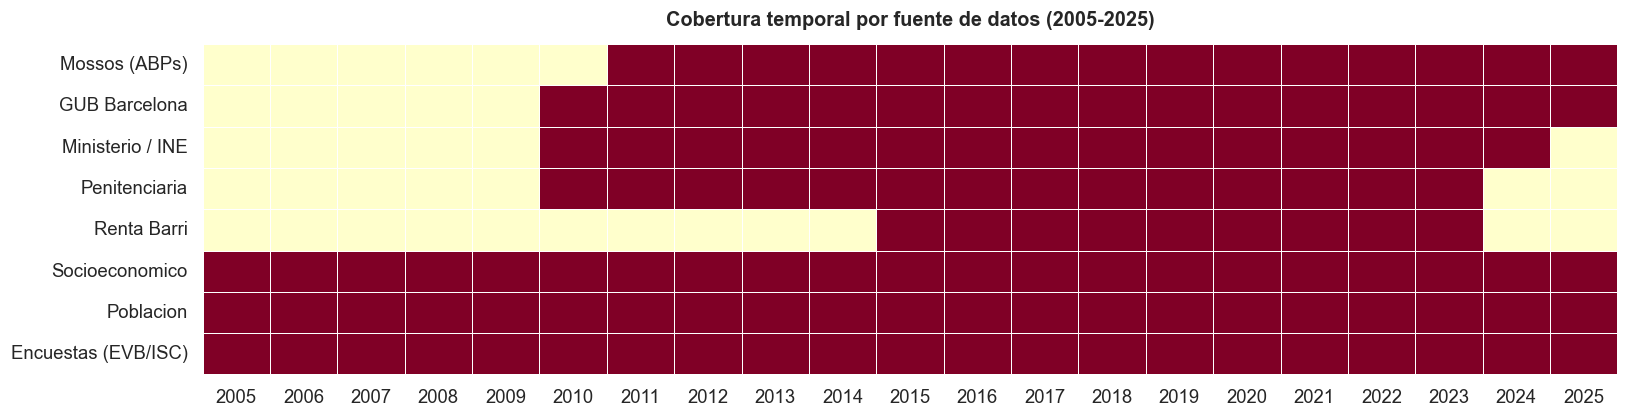

,Desde,Hasta,Registros
Fuente,,,
Mossos (ABPs),2011,2025,"321,188"
GUB Barcelona,2010,2025,"543,709"
Ministerio / INE,2010,2024,"22,248"
Penitenciaria,2010,2023,"12,240"
Renta Barri,2015,2023,"1,241"
Socioeconomico,1981,2025,"1,247"
Poblacion,1998,2025,"79,587"
Encuestas (EVB/ISC),1983,2030,513


In [6]:
# Cobertura temporal por fuente
m_t = fact_mossos.merge(dim_tiempo[['id_tiempo','anyo']], on='id_tiempo')
g_t = fact_gub.merge(   dim_tiempo[['id_tiempo','anyo']], on='id_tiempo')
c_t = fact_crim.merge(  dim_tiempo[['id_tiempo','anyo']], on='id_tiempo')

_fuentes = {
    'Mossos (ABPs)':       (int(m_t['anyo'].min()),             int(m_t['anyo'].max()),             len(fact_mossos)),
    'GUB Barcelona':       (int(g_t['anyo'].min()),             int(g_t['anyo'].max()),             len(fact_gub)),
    'Ministerio / INE':    (int(c_t['anyo'].min()),             int(c_t['anyo'].max()),             len(fact_crim)),
    'Penitenciaria':       (int(ctx_penitenciaria['anyo'].min()),int(ctx_penitenciaria['anyo'].max()),len(ctx_penitenciaria)),
    'Renta Barri':         (int(ctx_renta_barri['anyo'].min()),  int(ctx_renta_barri['anyo'].max()),  len(ctx_renta_barri)),
    'Socioeconomico':      (int(ctx_socio['anyo'].min()),        int(ctx_socio['anyo'].max()),        len(ctx_socio)),
    'Poblacion':           (int(ctx_poblacion['anyo'].min()),    int(ctx_poblacion['anyo'].max()),    len(ctx_poblacion)),
    'Encuestas (EVB/ISC)': (int(ctx_encuestas['anyo'].min()),   int(ctx_encuestas['anyo'].max()),    len(ctx_encuestas)),
}

years = list(range(2005, 2026))
cob = pd.DataFrame(0, index=list(_fuentes.keys()), columns=years)
for fuente, (y0, y1, _) in _fuentes.items():
    for y in range(max(y0, 2005), min(y1, 2025)+1):
        cob.loc[fuente, y] = 1

fig, ax = plt.subplots(figsize=(15, 4))
sns.heatmap(cob, ax=ax, cmap='YlOrRd', cbar=False, linewidths=0.5, linecolor='white')
ax.set_title('Cobertura temporal por fuente de datos (2005-2025)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

display(pd.DataFrame([
    {'Fuente': k, 'Desde': v[0], 'Hasta': v[1], 'Registros': f"{v[2]:,}"}
    for k, v in _fuentes.items()
]).set_index('Fuente'))

---
<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 30px;border-radius:10px;margin:20px 0;">
  <h2 style="color:#fff;margin:0;font-size:1.6em;">2 · Evolución temporal de la criminalidad</h2>
  <p style="color:#a8b0c0;margin:8px 0 0 0;">¿Cataluña es más o menos segura que hace 15 años?</p>
</div>

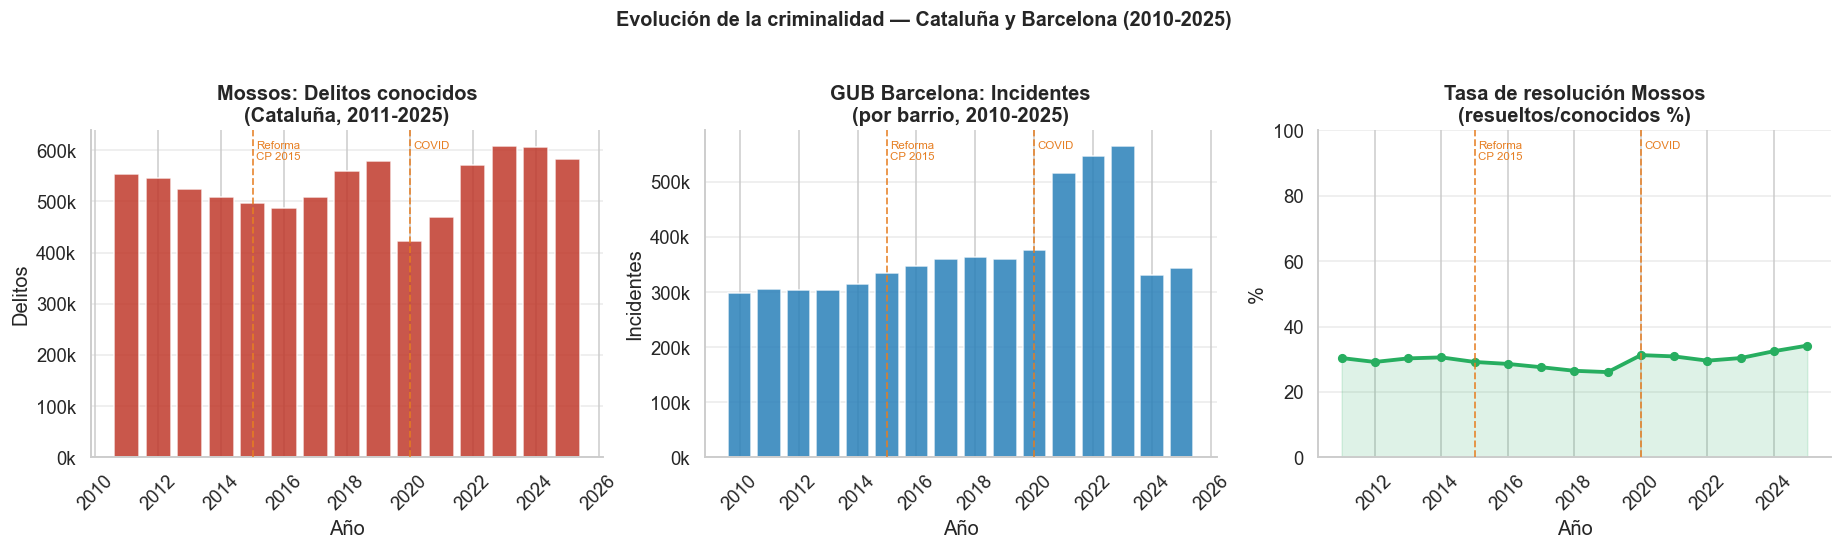

In [7]:
# Tendencias anuales Mossos + GUB
mossos_t  = fact_mossos.merge(dim_tiempo[['id_tiempo','anyo']], on='id_tiempo')
mossos_an = mossos_t.groupby('anyo')[['coneguts','resolts','detencions']].sum().reset_index()
mossos_an['tasa_resolucion'] = (mossos_an['resolts'] / mossos_an['coneguts'] * 100).round(1)

gub_t  = fact_gub.merge(dim_tiempo[['id_tiempo','anyo']], on='id_tiempo')
gub_an = gub_t.groupby('anyo')['num_incidents'].sum().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ax = axes[0]
ax.bar(mossos_an['anyo'], mossos_an['coneguts'], color=COL_CRIME, alpha=0.85, zorder=2)
ax.set_title('Mossos: Delitos conocidos\n(Cataluña, 2011-2025)', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Delitos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))
ax.tick_params(axis='x', rotation=45); ax.grid(axis='y', alpha=0.4, zorder=1)
ax.axvline(2015, color='#e67e22', linestyle='--', linewidth=1.2, alpha=0.85, zorder=3)
ax.text(2015.1, 0.97, 'Reforma\nCP 2015', transform=ax.get_xaxis_transform(), fontsize=7.5, color='#e67e22', va='top')
ax.axvline(2020, color='#e67e22', linestyle='--', linewidth=1.2, alpha=0.85, zorder=3)
ax.text(2020.1, 0.97, 'COVID', transform=ax.get_xaxis_transform(), fontsize=7.5, color='#e67e22', va='top')

ax = axes[1]
ax.bar(gub_an['anyo'], gub_an['num_incidents'], color=COL_GUB, alpha=0.85, zorder=2)
ax.set_title('GUB Barcelona: Incidentes\n(por barrio, 2010-2025)', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Incidentes')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))
ax.tick_params(axis='x', rotation=45); ax.grid(axis='y', alpha=0.4, zorder=1)
ax.axvline(2015, color='#e67e22', linestyle='--', linewidth=1.2, alpha=0.85, zorder=3)
ax.text(2015.1, 0.97, 'Reforma\nCP 2015', transform=ax.get_xaxis_transform(), fontsize=7.5, color='#e67e22', va='top')
ax.axvline(2020, color='#e67e22', linestyle='--', linewidth=1.2, alpha=0.85, zorder=3)
ax.text(2020.1, 0.97, 'COVID', transform=ax.get_xaxis_transform(), fontsize=7.5, color='#e67e22', va='top')

ax = axes[2]
ax.plot(mossos_an['anyo'], mossos_an['tasa_resolucion'],
        color=COL_RESOLVE, linewidth=2.5, marker='o', markersize=5, zorder=2)
ax.fill_between(mossos_an['anyo'], mossos_an['tasa_resolucion'], alpha=0.15, color=COL_RESOLVE)
ax.set_title('Tasa de resolución Mossos\n(resueltos/conocidos %)', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('%'); ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=45); ax.grid(axis='y', alpha=0.4, zorder=1)
ax.axvline(2015, color='#e67e22', linestyle='--', linewidth=1.2, alpha=0.85, zorder=3)
ax.text(2015.1, 0.97, 'Reforma\nCP 2015', transform=ax.get_xaxis_transform(), fontsize=7.5, color='#e67e22', va='top')
ax.axvline(2020, color='#e67e22', linestyle='--', linewidth=1.2, alpha=0.85, zorder=3)
ax.text(2020.1, 0.97, 'COVID', transform=ax.get_xaxis_transform(), fontsize=7.5, color='#e67e22', va='top')

plt.suptitle('Evolución de la criminalidad — Cataluña y Barcelona (2010-2025)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [8]:
# Tasa per capita (delitos por 100.000 habitantes)
pob_cat = ctx_poblacion[
    (ctx_poblacion['nivel_territorial'] == 'ccaa') &
    (ctx_poblacion['sexe'] == 'Total')
][['anyo','valor']].rename(columns={'valor':'poblacion'})

tasas = mossos_an[['anyo','coneguts','detencions']].merge(pob_cat, on='anyo', how='inner')
tasas['tasa_delitos_100k']    = (tasas['coneguts']   / tasas['poblacion'] * 100_000).round(1)
tasas['tasa_detencions_100k'] = (tasas['detencions'] / tasas['poblacion'] * 100_000).round(1)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=tasas['anyo'], y=tasas['tasa_delitos_100k'],
    name='Delitos / 100k hab', mode='lines+markers',
    line=dict(color='#e74c3c', width=2.5), marker=dict(size=7)
))
fig.add_trace(go.Scatter(
    x=tasas['anyo'], y=tasas['tasa_detencions_100k'],
    name='Detenciones / 100k hab', mode='lines+markers',
    line=dict(color='#27ae60', width=2.5, dash='dash'), marker=dict(size=7)
))
fig.update_layout(
    title='Tasa de criminalidad por 100.000 habitantes — Cataluña',
    xaxis_title='Año', yaxis_title='Tasa (por 100k hab)',
    template='plotly_white', hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02), height=420
)
fig.add_vline(x=2015, line_width=1.5, line_dash='dash', line_color='#e67e22',
              annotation_text='Reforma CP 2015', annotation_position='top right',
              annotation_font_size=11, annotation_font_color='#e67e22')
fig.add_vline(x=2020, line_width=1.5, line_dash='dash', line_color='#e67e22',
              annotation_text='COVID', annotation_position='top right',
              annotation_font_size=11, annotation_font_color='#e67e22')
fig.show()

<div style="background:#fef9e7;border-left:4px solid #f39c12;padding:15px 20px;border-radius:6px;margin:10px 0;">
<strong>Hallazgo clave:</strong> Analizar la criminalidad en términos per cápita es más honesto que en términos absolutos, dado el crecimiento poblacional de Cataluña (de ~7,4M en 2011 a ~7,9M en 2023). El confinamiento de 2020 marca una caída brusca y artificial en todos los indicadores.
</div>

---
<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 30px;border-radius:10px;margin:20px 0;">
  <h2 style="color:#fff;margin:0;font-size:1.6em;">3 · Geografía del crimen</h2>
  <p style="color:#a8b0c0;margin:8px 0 0 0;">¿Dónde se concentran los delitos en Cataluña y Barcelona?</p>
</div>

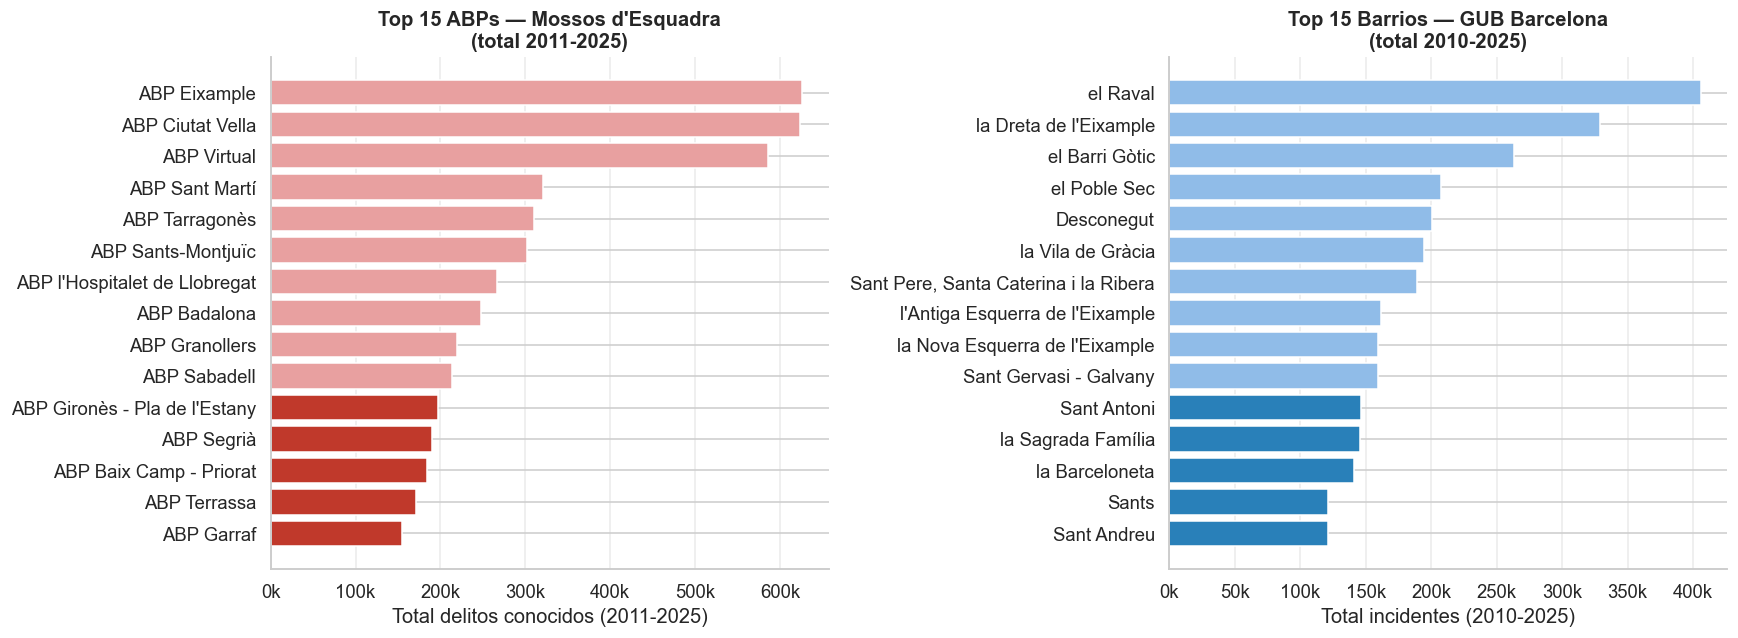

In [9]:
# Rankings: top ABPs Mossos y top barrios GUB
mossos_terr = fact_mossos.merge(
    dim_territorio[['id_territorio','abp','region_policial','nivel_territorial']],
    on='id_territorio'
)
top_abp = (mossos_terr[mossos_terr['nivel_territorial']=='abp']
           .groupby(['abp','region_policial'])['coneguts'].sum()
           .reset_index().nlargest(15,'coneguts'))

gub_terr = fact_gub.merge(
    dim_territorio[['id_territorio','nom_barri','nom_districte','nivel_territorial']],
    on='id_territorio'
)
top_barri = (gub_terr[gub_terr['nivel_territorial']=='barri']
             .groupby(['nom_barri','nom_districte'])['num_incidents'].sum()
             .reset_index().nlargest(15,'num_incidents'))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
colors_a = [COL_CRIME if i < 5 else '#e8a0a0' for i in range(len(top_abp))]
ax.barh(top_abp['abp'], top_abp['coneguts'], color=colors_a[::-1], zorder=2)
ax.set_xlabel('Total delitos conocidos (2011-2025)'); ax.invert_yaxis()
ax.set_title("Top 15 ABPs — Mossos d'Esquadra\n(total 2011-2025)", fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))
ax.grid(axis='x', alpha=0.4, zorder=1)

ax = axes[1]
colors_b = [COL_GUB if i < 5 else '#90bce8' for i in range(len(top_barri))]
ax.barh(top_barri['nom_barri'], top_barri['num_incidents'], color=colors_b[::-1], zorder=2)
ax.set_xlabel('Total incidentes (2010-2025)'); ax.invert_yaxis()
ax.set_title('Top 15 Barrios — GUB Barcelona\n(total 2010-2025)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))
ax.grid(axis='x', alpha=0.4, zorder=1)

plt.tight_layout(); plt.show()

In [10]:
# Mapa coropletico de Barcelona por barri (plotly + shapely)
try:
    from shapely.wkt import loads as wkt_loads
    from shapely.geometry import mapping

    geo_barri = geo[geo['nivel_territorial']=='barri'].copy()
    features = []
    for _, row in geo_barri.iterrows():
        try:
            geom = wkt_loads(row['geometria_wgs84']).simplify(0.0001, preserve_topology=True)
            features.append({
                'type': 'Feature',
                'geometry': mapping(geom),
                'properties': {'id_territorio': int(row['id_territorio']), 'nom': str(row['nom'])}
            })
        except Exception:
            pass

    geojson_barri = {'type':'FeatureCollection','features': features}

    tot_barri_mapa = (fact_gub.groupby('id_territorio')['num_incidents']
                      .sum().reset_index()
                      .merge(dim_territorio[['id_territorio','nom_barri','nom_districte']], on='id_territorio'))

    fig = px.choropleth_mapbox(
        tot_barri_mapa, geojson=geojson_barri,
        locations='id_territorio', featureidkey='properties.id_territorio',
        color='num_incidents', hover_name='nom_barri',
        hover_data={'nom_districte': True, 'num_incidents': ':,.0f', 'id_territorio': False},
        color_continuous_scale='Reds', mapbox_style='open-street-map',
        center={'lat':41.3851,'lon':2.1734}, zoom=11, opacity=0.75,
        title='Total incidentes GUB por barrio — Barcelona (2010-2025)',
        labels={'num_incidents':'Incidentes'}
    )
    fig.update_layout(height=560, margin={'r':0,'t':50,'l':0,'b':0})
    fig.show()

except ImportError:
    print("shapely no disponible: pip install shapely")
    dist_sum = gub_terr.groupby('nom_districte')['num_incidents'].sum().reset_index()
    fig = px.bar(dist_sum.sort_values('num_incidents'),
                 x='num_incidents', y='nom_districte', orientation='h',
                 title='Total incidentes GUB por distrito (2010-2025)',
                 color='num_incidents', color_continuous_scale='Reds')
    fig.show()

<div style="background:#fef9e7;border-left:4px solid #f39c12;padding:15px 20px;border-radius:6px;margin:10px 0;">
<strong>Hallazgo clave:</strong> La criminalidad no está distribuida de forma uniforme — pocos barrios y ABPs concentran la mayor parte de los delitos. Este patrón de concentración espacial es la base del modelo ML de predicción de localización.
</div>

---
<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 30px;border-radius:10px;margin:20px 0;">
  <h2 style="color:#fff;margin:0;font-size:1.6em;">4 · Tipología delictiva</h2>
  <p style="color:#a8b0c0;margin:8px 0 0 0;">¿Qué tipos de delito predominan? ¿Cómo evolucionan los de mayor impacto social?</p>
</div>

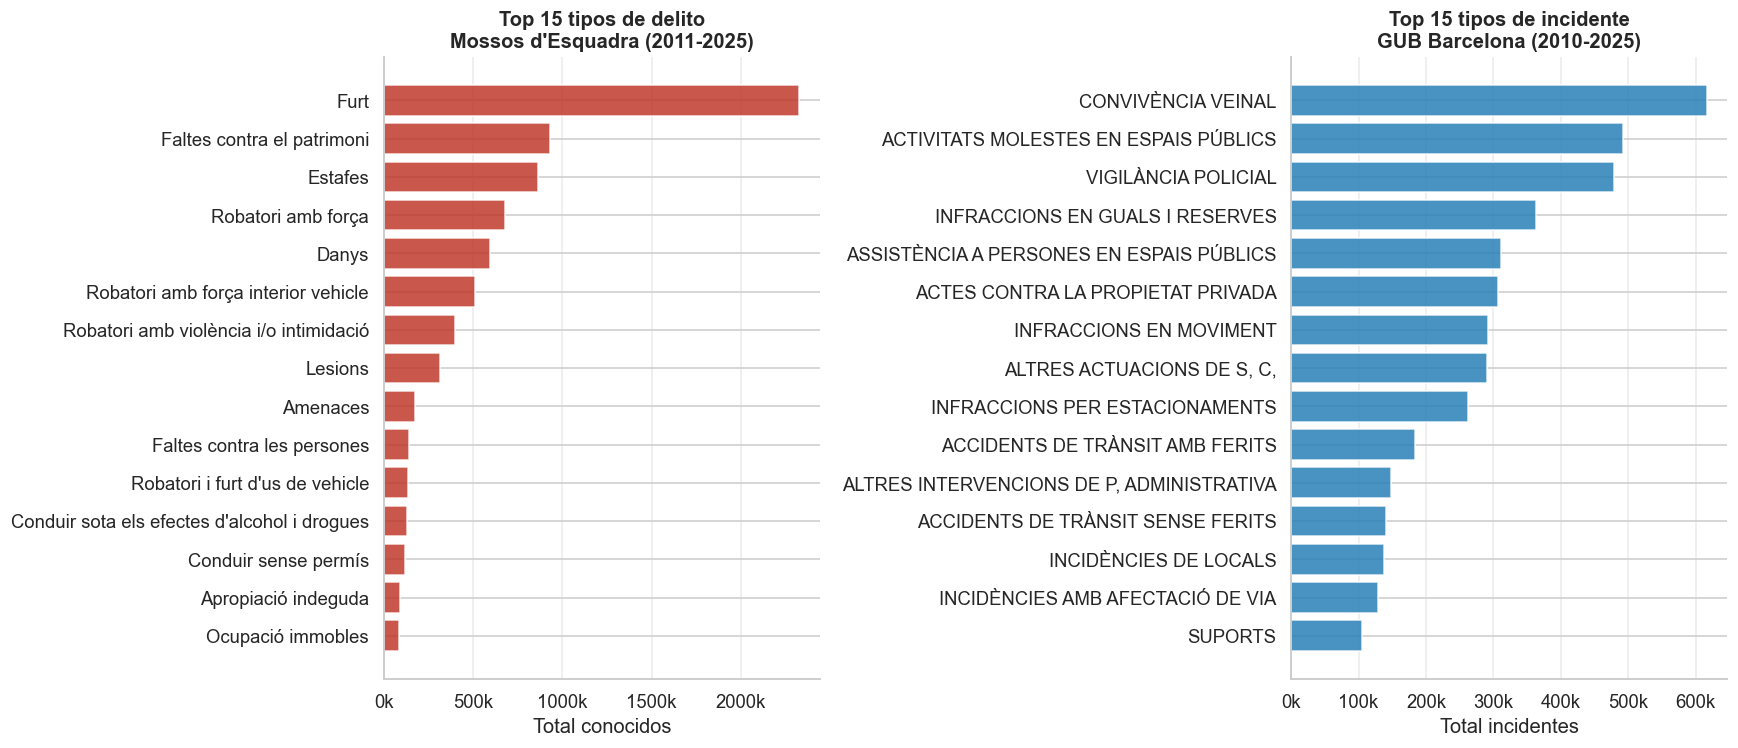

In [11]:
# Top tipos de delito por fuente (nivel detalle)
mossos_tipo = fact_mossos.merge(
    dim_tipo_delito[['id_tipo_delito','descripcio','nivel_tipologia','categoria']],
    on='id_tipo_delito'
)
gub_tipo = fact_gub.merge(
    dim_tipo_delito[['id_tipo_delito','descripcio','nivel_tipologia']],
    left_on='id_tipo_incident', right_on='id_tipo_delito'
)

top_mossos = (mossos_tipo[mossos_tipo['nivel_tipologia']=='detalle']
              .groupby('descripcio')['coneguts'].sum().nlargest(15).reset_index())
top_gub    = (gub_tipo[gub_tipo['nivel_tipologia']=='detalle']
              .groupby('descripcio')['num_incidents'].sum().nlargest(15).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.barh(top_mossos['descripcio'], top_mossos['coneguts'], color=COL_CRIME, alpha=0.85, zorder=2)
ax.set_title("Top 15 tipos de delito\nMossos d'Esquadra (2011-2025)", fontweight='bold')
ax.set_xlabel('Total conocidos'); ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))
ax.grid(axis='x', alpha=0.4, zorder=1)

ax = axes[1]
ax.barh(top_gub['descripcio'], top_gub['num_incidents'], color=COL_GUB, alpha=0.85, zorder=2)
ax.set_title('Top 15 tipos de incidente\nGUB Barcelona (2010-2025)', fontweight='bold')
ax.set_xlabel('Total incidentes'); ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))
ax.grid(axis='x', alpha=0.4, zorder=1)

plt.tight_layout(); plt.show()

In [12]:
# Evolucion temporal delitos de mayor impacto (objetivo ML)
# Claves: etiquetas en espanol (leyenda); valores: keywords busqueda en BD (catalan)
# nivel_tipologia=='detalle' garantiza nodos hoja — no hay doble conteo padre+hijo
DELITOS_ML = {
    'Homicidios':             'homicidi',
    'Asesinatos':             'assassinat',
    'Robos':                  'robatori',
    'Agresiones / Ab. sex.':  'agress',
}

mossos_ml = mossos_tipo[mossos_tipo['nivel_tipologia']=='detalle'].copy()
mossos_ml_t = mossos_ml.merge(dim_tiempo[['id_tiempo','anyo']], on='id_tiempo')

fig = go.Figure()
_colors = ['#e74c3c','#c0392b','#e67e22','#9b59b6']
for (nom, kw), col in zip(DELITOS_ML.items(), _colors):
    mask  = mossos_ml_t['descripcio'].str.lower().str.contains(kw, na=False)
    serie = mossos_ml_t[mask].groupby('anyo')['coneguts'].sum().reset_index()
    fig.add_trace(go.Scatter(
        x=serie['anyo'], y=serie['coneguts'], name=nom,
        mode='lines+markers', line=dict(color=col, width=2.5), marker=dict(size=6)
    ))

fig.update_layout(
    title="Evolución anual de los delitos de mayor impacto — Mossos d'Esquadra",
    xaxis_title='Año', yaxis_title='Delitos conocidos',
    template='plotly_white', hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02), height=430
)
fig.add_vline(x=2015, line_width=1.5, line_dash='dash', line_color='#e67e22',
              annotation_text='Reforma CP 2015', annotation_position='top right',
              annotation_font_size=11, annotation_font_color='#e67e22')
fig.add_vline(x=2020, line_width=1.5, line_dash='dash', line_color='#e67e22',
              annotation_text='COVID', annotation_position='top right',
              annotation_font_size=11, annotation_font_color='#e67e22')
fig.show()

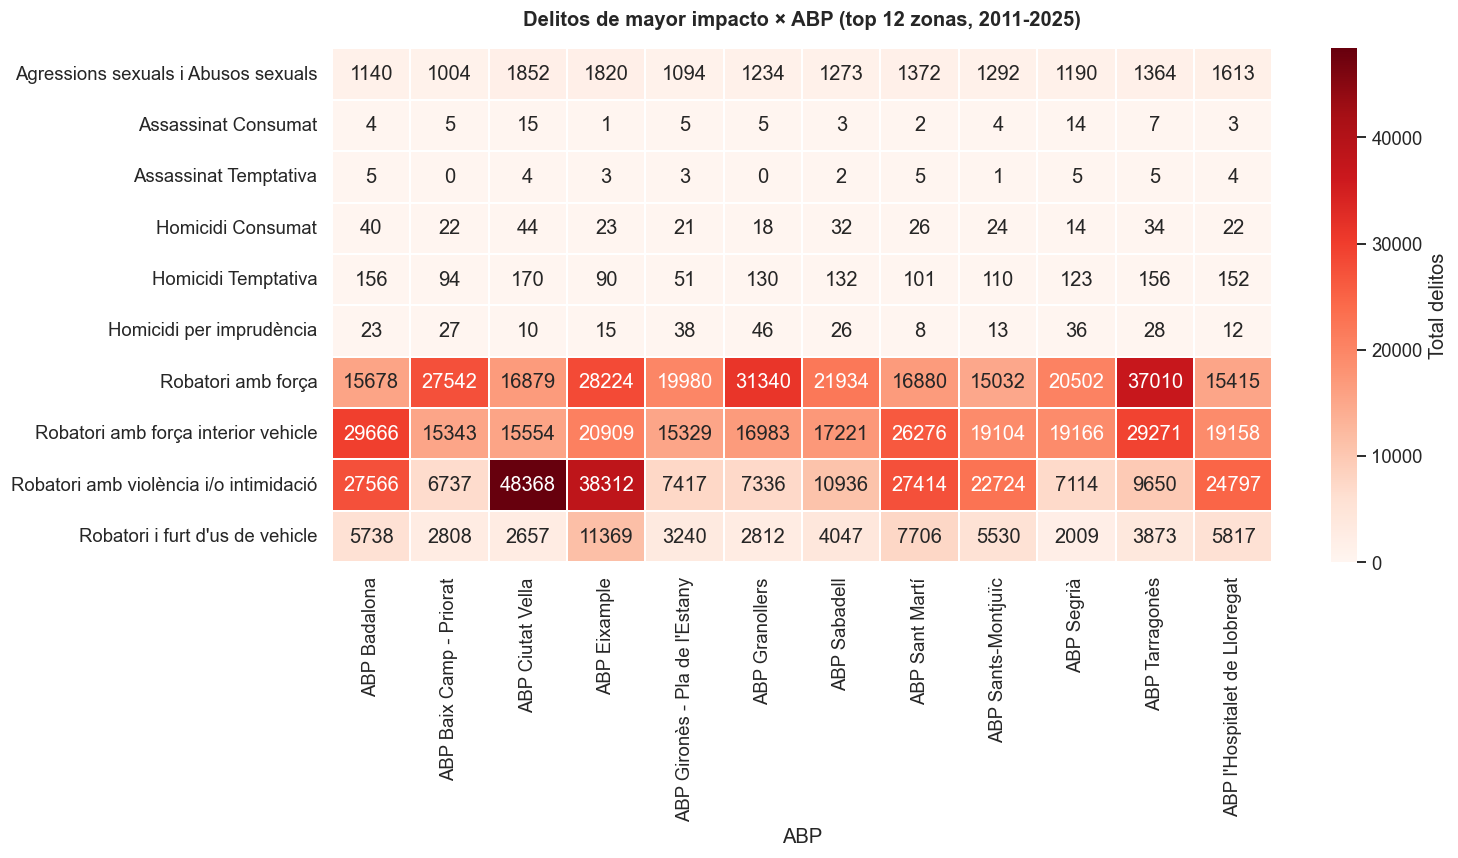

In [13]:
# Heatmap: tipo delito ML x ABP (top 12 zonas)
mossos_ml_terr = mossos_ml_t.merge(
    dim_territorio[['id_territorio','abp','nivel_territorial']], on='id_territorio'
)
mossos_ml_terr = mossos_ml_terr[mossos_ml_terr['nivel_territorial']=='abp']

kws_ml = list(DELITOS_ML.values())
mask_all = mossos_ml_terr['descripcio'].str.lower().str.contains('|'.join(kws_ml), na=False)
ml_sub   = mossos_ml_terr[mask_all].copy()

top12_abp = (ml_sub.groupby('abp')['coneguts'].sum().nlargest(12).index.tolist())
pivot = (ml_sub[ml_sub['abp'].isin(top12_abp)]
         .groupby(['descripcio','abp'])['coneguts'].sum()
         .unstack(fill_value=0))
pivot.index = [d[:38]+'...' if len(d)>38 else d for d in pivot.index]

fig, ax = plt.subplots(figsize=(14, max(5, len(pivot)*0.6+2)))
sns.heatmap(pivot, cmap='Reds', ax=ax, linewidths=0.3,
            fmt='.0f', annot=True, cbar_kws={'label':'Total delitos'})
ax.set_title('Delitos de mayor impacto × ABP (top 12 zonas, 2011-2025)',
             fontweight='bold', pad=15)
ax.set_xlabel('ABP'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

<div style="background:#fef9e7;border-left:4px solid #f39c12;padding:15px 20px;border-radius:6px;margin:10px 0;">
<strong>Hallazgo clave:</strong> Los robos representan la categoría dominante con gran diferencia. Los delitos sexuales, aunque menos frecuentes, requieren atención especial en el modelo ML. La concentración por ABP varía significativamente según el tipo de delito.
</div>

---
<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 30px;border-radius:10px;margin:20px 0;">
  <h2 style="color:#fff;margin:0;font-size:1.6em;">5 · Perfil socioeconómico y correlación con el crimen</h2>
  <p style="color:#a8b0c0;margin:8px 0 0 0;">¿Existe relación entre renta, educación y la tasa de criminalidad por barrio?</p>
</div>

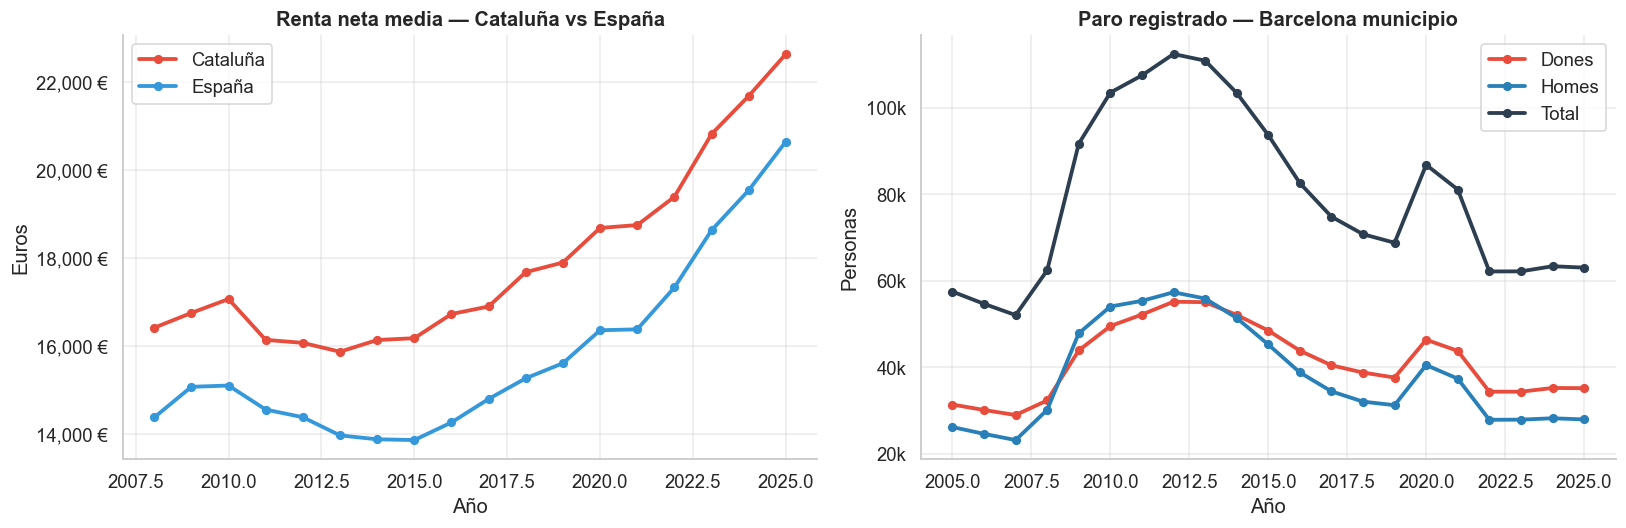

In [14]:
# Renta neta media (temporal) y Paro Barcelona
renta = ctx_socio[ctx_socio['indicador']=='renta_neta_media'].copy()
renta_grp = renta.groupby(['anyo','territori'])['valor'].mean().reset_index()

paro = ctx_socio[ctx_socio['indicador']=='paro_registrat'].copy()
paro_grp = paro.groupby(['anyo','sexe'])['valor'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for terr, col in [('Cataluña','#e74c3c'),('España','#3498db'),('Cataluna','#e74c3c')]:
    sub = renta_grp[renta_grp['territori'].str.lower().str.contains(terr.lower(), na=False)]
    sub_clean = sub.groupby('anyo')['valor'].mean().reset_index()
    if len(sub_clean):
        ax.plot(sub_clean['anyo'], sub_clean['valor'], label=terr.replace('Cataluna','Cataluña'),
                color=col, linewidth=2.5, marker='o', markersize=5)
# Evitar etiqueta duplicada
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
ax.set_title('Renta neta media — Cataluña vs España', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Euros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f} €'))
ax.grid(alpha=0.4)

ax = axes[1]
_sex_colors = {'Total':'#2c3e50','Hombres':'#2980b9','Mujeres':'#e74c3c',
               'Homes':'#2980b9','Dones':'#e74c3c'}
for sexe_val in paro_grp['sexe'].dropna().unique():
    sub = paro_grp[paro_grp['sexe']==sexe_val]
    col = _sex_colors.get(sexe_val, '#95a5a6')
    ax.plot(sub['anyo'], sub['valor'], label=sexe_val, color=col,
            linewidth=2.5, marker='o', markersize=5)
ax.set_title('Paro registrado — Barcelona municipio', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Personas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))
ax.legend(); ax.grid(alpha=0.4)


plt.tight_layout(); plt.show()

In [15]:
# Scatter: Renta por barrio x Incidentes GUB (absolutos y per capita)
tot_gub_barri = (fact_gub.groupby('id_territorio')['num_incidents']
                 .sum().reset_index()
                 .rename(columns={'num_incidents':'total_incidentes'}))

renta_barri_avg = (ctx_renta_barri[ctx_renta_barri['indicador']=='renta_tributaria_barri']
                   .groupby('id_territori')['valor'].mean().reset_index()
                   .rename(columns={'id_territori':'id_territorio','valor':'renta_media'}))

scatter_renta = (tot_gub_barri
    .merge(renta_barri_avg, on='id_territorio')
    .merge(dim_territorio[['id_territorio','nom_barri','nom_districte']], on='id_territorio'))

# Poblacion adulta por barrio derivada de nivell_educatiu (suma de todos los niveles).
# ctx_poblacion no tiene desglose por barri (solo municipi/ccaa), por eso usamos
# nivell_educatiu como proxy de poblacion residente adulta del barrio.
_pob_barri = (ctx_socio[
        (ctx_socio['indicador'] == 'nivell_educatiu') &
        (ctx_socio['nivel_territorial'] == 'barri')
    ].groupby('id_territori')['valor'].sum().reset_index()
     .rename(columns={'id_territori': 'id_territorio', 'valor': 'poblacion_adulta'}))

scatter_renta = scatter_renta.merge(_pob_barri, on='id_territorio', how='left')
scatter_renta['incidentes_per_1000'] = (
    scatter_renta['total_incidentes'] / scatter_renta['poblacion_adulta'] * 1000
).round(1)
_percapita_ok = scatter_renta['incidentes_per_1000'].notna().sum() > 10

# ── Scatter 1: incidentes absolutos (confundido por afluencia/turismo) ──
rho, pval = scipy_stats.spearmanr(scatter_renta['renta_media'], scatter_renta['total_incidentes'])
fig = px.scatter(
    scatter_renta, x='renta_media', y='total_incidentes',
    hover_name='nom_barri',
    hover_data={'nom_districte':True,'renta_media':':,.0f','total_incidentes':':,.0f','id_territorio':False},
    color='total_incidentes', color_continuous_scale='Reds',
    size='total_incidentes', size_max=30,
    labels={'renta_media':'Renta tributaria media (EUR/hab, 2015-2023)',
            'total_incidentes':'Incidentes GUB absolutos'},
    title=f'Renta vs Incidentes absolutos — Barcelona  (rho = {rho:+.2f}, p={pval:.3f})',
    template='plotly_white'
)
fig.update_layout(height=480)
fig.show()
print(f"Incidentes absolutos: rho={rho:+.3f}  -> POSITIVO por sesgo de exposicion (centro/turismo), no causalidad")

# ── Scatter 2: incidentes per capita (corrige sesgo de afluencia si hay datos) ──
if _percapita_ok:
    _sc2 = scatter_renta.dropna(subset=['incidentes_per_1000'])
    rho2, pval2 = scipy_stats.spearmanr(_sc2['renta_media'], _sc2['incidentes_per_1000'])
    fig2 = px.scatter(
        _sc2, x='renta_media', y='incidentes_per_1000',
        hover_name='nom_barri',
        hover_data={'nom_districte':True,'renta_media':':,.0f','incidentes_per_1000':':.1f','id_territorio':False},
        color='incidentes_per_1000', color_continuous_scale='RdBu_r',
        size='incidentes_per_1000', size_max=30,
        labels={'renta_media':'Renta tributaria media (EUR/hab)',
                'incidentes_per_1000':'Incidentes por 1.000 hab.'},
        title=f'Renta vs Incidentes per capita — Barcelona  (rho = {rho2:+.2f}, p={pval2:.3f})',
        template='plotly_white'
    )
    fig2.update_layout(height=480)
    fig2.show()
    print(f"Per capita: rho={rho2:+.3f}  — normalizado por poblacion residente del barrio")
else:
    print("Datos de poblacion a nivel barrio no disponibles en ctx_poblacion — ver scatter absoluto arriba")


Incidentes absolutos: rho=+0.327  -> POSITIVO por sesgo de exposicion (centro/turismo), no causalidad


Per capita: rho=-0.044  — normalizado por poblacion residente del barrio


In [16]:
# Scatter: Nivel educativo x Incidentes GUB (proporción real, absolutos y per cápita)
# El valor de nivell_educatiu son PERSONAS, no %. Calculamos la proporción real
# (personas baja educación / población adulta del barrio) y normalizamos incidentes.
_edu_raw = ctx_socio[(ctx_socio['indicador'] == 'nivell_educatiu') &
                     (ctx_socio['nivel_territorial'] == 'barri')].copy()

def _prop_y_pob(g):
    tot = g['valor'].sum()
    baja = g[g['categoria'].fillna('').str.lower()
             .str.contains('primaria o inferior', na=False)]['valor'].sum()
    return pd.Series({'pct': baja / tot * 100 if tot > 0 else np.nan, 'pob_adulta': tot})

_agg = _edu_raw.groupby(['id_territori', 'anyo']).apply(_prop_y_pob).reset_index()
edu_barri = (_agg.groupby('id_territori')
             .agg(pct_baja_edu=('pct', 'mean'), pob_adulta=('pob_adulta', 'mean'))
             .reset_index().rename(columns={'id_territori': 'id_territorio'}))

scatter_edu = (tot_gub_barri
    .merge(edu_barri, on='id_territorio')
    .merge(dim_territorio[['id_territorio', 'nom_barri', 'nom_districte']], on='id_territorio'))
scatter_edu['incidentes_per_1000'] = (
    scatter_edu['total_incidentes'] / scatter_edu['pob_adulta'] * 1000).round(1)
scatter_edu['pct_baja_edu'] = scatter_edu['pct_baja_edu'].round(1)

if len(scatter_edu) > 3:
    # Scatter 1: absoluto
    rho_e, p_e = scipy_stats.spearmanr(scatter_edu['pct_baja_edu'], scatter_edu['total_incidentes'])
    fig = px.scatter(
        scatter_edu, x='pct_baja_edu', y='total_incidentes', hover_name='nom_barri',
        hover_data={'nom_districte': True, 'pct_baja_edu': ':.1f', 'total_incidentes': ':,.0f', 'id_territorio': False},
        color='total_incidentes', color_continuous_scale='Reds', size='total_incidentes', size_max=30,
        labels={'pct_baja_edu': '% población con educación primaria o inferior',
                'total_incidentes': 'Incidentes GUB absolutos'},
        title=f'Educación vs Incidentes absolutos — Barcelona  (rho = {rho_e:+.2f}, p={p_e:.3f})',
        template='plotly_white')
    fig.update_layout(height=480); fig.show()
    print(f'Educación absoluto: rho={rho_e:+.3f} (p={p_e:.4f}) -> confundido por tamaño del barrio')

    # Scatter 2: per cápita
    rho_e2, p_e2 = scipy_stats.spearmanr(scatter_edu['pct_baja_edu'], scatter_edu['incidentes_per_1000'])
    fig2 = px.scatter(
        scatter_edu, x='pct_baja_edu', y='incidentes_per_1000', hover_name='nom_barri',
        hover_data={'nom_districte': True, 'pct_baja_edu': ':.1f', 'incidentes_per_1000': ':.1f', 'id_territorio': False},
        color='incidentes_per_1000', color_continuous_scale='RdBu_r', size='incidentes_per_1000', size_max=30,
        labels={'pct_baja_edu': '% población con educación primaria o inferior',
                'incidentes_per_1000': 'Incidentes por 1.000 hab.'},
        title=f'Educación vs Incidentes per cápita — Barcelona  (rho = {rho_e2:+.2f}, p={p_e2:.3f})',
        template='plotly_white')
    fig2.update_layout(height=480); fig2.show()
    print(f'Educación per cápita: rho={rho_e2:+.3f} (p={p_e2:.4f}) -> se anula, igual que la renta')
else:
    print('Pocos barrios con datos de educacion para el scatter')


Educación absoluto: rho=-0.366 (p=0.0016) -> confundido por tamaño del barrio


Educación per cápita: rho=-0.012 (p=0.9227) -> se anula, igual que la renta


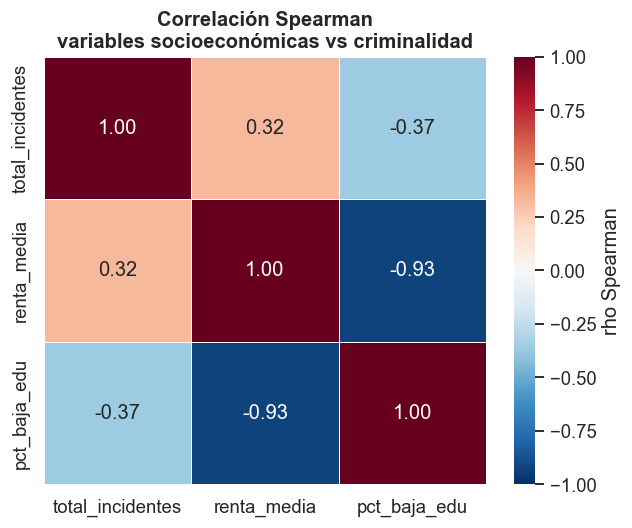

N barrios con datos completos: 72


In [17]:
# Matriz de correlacion (Spearman)
_feat_df = tot_gub_barri.merge(renta_barri_avg, on='id_territorio', how='left')
if 'pct_baja_edu' in edu_barri.columns:
    _feat_df = _feat_df.merge(edu_barri, on='id_territorio', how='left')

_corr_cols = [c for c in ['total_incidentes','renta_media','pct_baja_edu'] if c in _feat_df.columns]
_corr_df   = _feat_df[_corr_cols].dropna()

if len(_corr_df) >= 5:
    _corr_mat = _corr_df.corr(method='spearman')
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(_corr_mat, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, linewidths=0.5,
                cbar_kws={'label':'rho Spearman'})
    ax.set_title('Correlación Spearman\nvariables socioeconómicas vs criminalidad', fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f"N barrios con datos completos: {len(_corr_df)}")
else:
    print("Datos insuficientes para la matriz de correlacion")

<div style="background:#fef9e7;border-left:4px solid #f39c12;padding:15px 20px;border-radius:6px;margin:10px 0;">
<strong>Hallazgo clave:</strong> La correlación renta–crimen es <strong>positiva (rho ≈ +0.33, p&lt;0.01)</strong>, contraintuitivamente. La explicación es el <strong>sesgo de exposición</strong>: los barrios con más incidentes son centros turísticos y comerciales (Eixample, Gòtic, Raval) que concentran afluencia de personas, no necesariamente pobreza. El número absoluto de incidentes está confundido por cuánta gente <em>transita</em> el barrio, no por cuánta gente <em>vive</em> en él. Para el modelo ML: usar incidentes <strong>per cápita</strong> o incluir variables de afluencia (transporte público, densidad comercial) como covariables. Al normalizar por población residente (N = 72 barrios), la correlación desaparece: <strong>rho ≈ −0.04, p = 0.72</strong>, confirmando que el efecto era íntegramente de exposición y no causal. Excepción: la <em>Marina del Prat Vermell</em> aparece como outlier (∼15.500 incidentes/1.000 hab) por ser zona industrial con muy pocos residentes censados, lo que ilustra que el per cápita también tiene límites en barrios no residenciales.
</div>

---
<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 30px;border-radius:10px;margin:20px 0;">
  <h2 style="color:#fff;margin:0;font-size:1.6em;">6 · Población penitenciaria en Cataluña</h2>
  <p style="color:#a8b0c0;margin:8px 0 0 0;">¿Quién está en prisión? Perfil por sexo, delito y nacionalidad (2010-2023)</p>
</div>

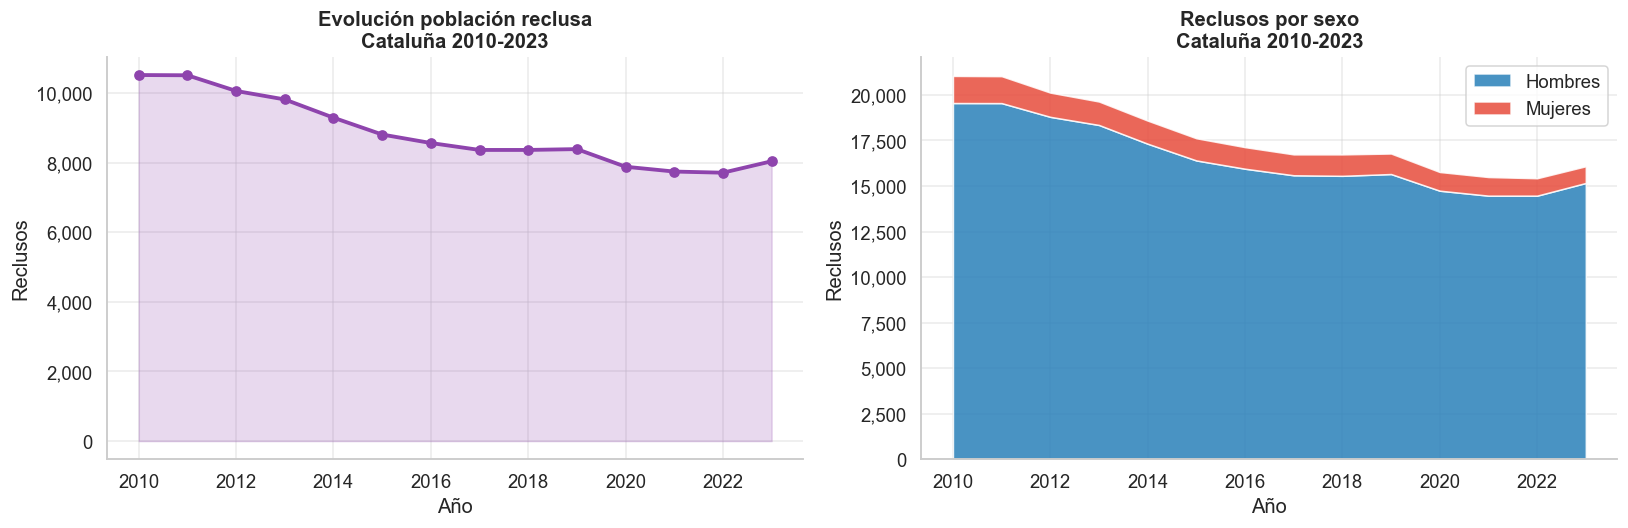

In [18]:
# Evolucion total reclusos y por sexo
reclusos_tot = (ctx_penitenciaria[
    (ctx_penitenciaria['desglose']=='nacionalitat') &
    (ctx_penitenciaria['categoria']=='Total')
].groupby('anyo')['valor'].sum().reset_index())

sexo_pen = (ctx_penitenciaria[
    (ctx_penitenciaria['desglose']=='regim_sexe') &
    (ctx_penitenciaria['sexe'].isin(['Homes','Dones']))
].groupby(['anyo','sexe'])['valor'].sum().unstack(fill_value=0).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.fill_between(reclusos_tot['anyo'], reclusos_tot['valor'], alpha=0.2, color=COL_SOCIO)
ax.plot(reclusos_tot['anyo'], reclusos_tot['valor'],
        color=COL_SOCIO, linewidth=2.5, marker='o', markersize=6)
ax.set_title('Evolución población reclusa\nCataluña 2010-2023', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Reclusos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.grid(alpha=0.4)

ax = axes[1]
if 'Homes' in sexo_pen.columns and 'Dones' in sexo_pen.columns:
    ax.stackplot(sexo_pen['anyo'],
                 [sexo_pen['Homes'], sexo_pen['Dones']],
                 labels=['Hombres','Mujeres'],
                 colors=['#2980b9','#e74c3c'], alpha=0.85)
    ax.set_title('Reclusos por sexo\nCataluña 2010-2023', fontweight='bold')
    ax.set_xlabel('Año'); ax.set_ylabel('Reclusos')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    ax.legend(loc='upper right'); ax.grid(alpha=0.4)

plt.tight_layout(); plt.show()

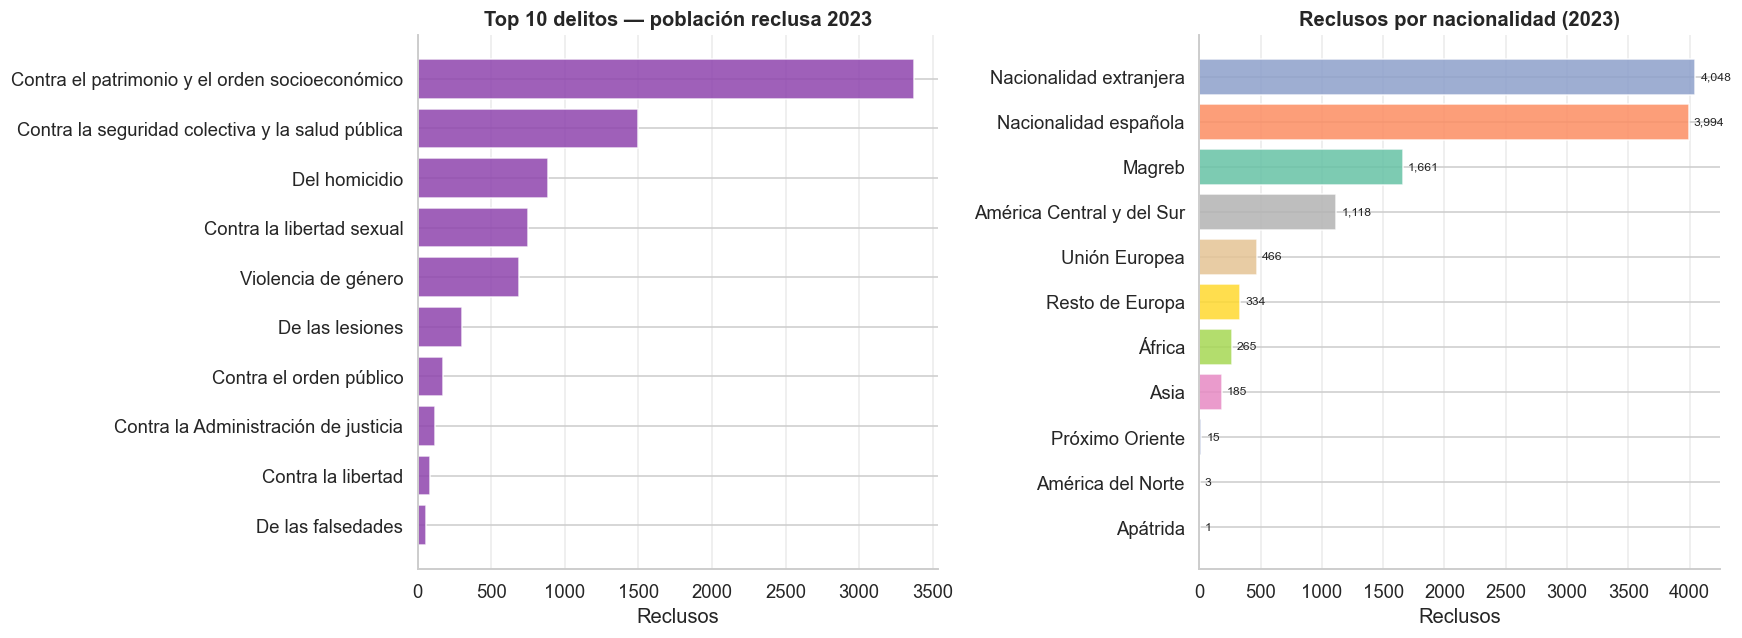

In [19]:
# Top tipos de delito penitenciario + distribucion por nacionalidad
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top delitos (2023)
anyo_max_pen = int(ctx_penitenciaria['anyo'].max())
pen_delicte = ctx_penitenciaria[
    (ctx_penitenciaria['desglose']=='edat_delicte') &
    (ctx_penitenciaria['anyo']==anyo_max_pen) &
    (ctx_penitenciaria['grup_edat'].fillna('').str.lower()=='total') &
    (ctx_penitenciaria['sexe'].fillna('').str.lower()=='total')
]
if len(pen_delicte):
    # Excloure subtotals (Total general i subtotals de codi penal)
    _excl = pen_delicte['categoria'].fillna('').str.startswith(('Total', 'Delitos ('))
    top_del = (pen_delicte[~_excl].groupby('categoria')['valor'].sum()
               .nlargest(10).reset_index())
    if len(top_del):
        axes[0].barh(top_del['categoria'], top_del['valor'], color=COL_SOCIO, alpha=0.85, zorder=2)
        axes[0].set_title(f'Top 10 delitos — población reclusa {anyo_max_pen}', fontweight='bold')
        axes[0].set_xlabel('Reclusos'); axes[0].invert_yaxis()
        axes[0].grid(axis='x', alpha=0.4, zorder=1)
    else:
        axes[0].text(0.5,0.5,'No hay datos de categoría\npara este año',
                     ha='center',va='center',transform=axes[0].transAxes, color='gray')
else:
    axes[0].text(0.5,0.5,'Revisar valores sexo/grupo_edad\nen el CSV penitenciaria',
                 ha='center',va='center',transform=axes[0].transAxes,
                 fontsize=10, color='gray')
    axes[0].set_title(f'Top delitos {anyo_max_pen}')

# Nacionalitat
nac = ctx_penitenciaria[
    (ctx_penitenciaria['desglose']=='nacionalitat') &
    (ctx_penitenciaria['anyo']==anyo_max_pen) &
    (ctx_penitenciaria['categoria']!='Total')
].groupby('categoria')['valor'].sum()
nac = nac[nac > 0].sort_values(ascending=False)
if len(nac):
    nac_clean = nac[nac > 0].sort_values(ascending=True)
    colors_nac = sns.color_palette('Set2', len(nac_clean))
    axes[1].barh(nac_clean.index, nac_clean.values, color=colors_nac, alpha=0.85, zorder=2)
    axes[1].set_title(f'Reclusos por nacionalidad ({anyo_max_pen})', fontweight='bold')
    axes[1].set_xlabel('Reclusos')
    axes[1].grid(axis='x', alpha=0.4, zorder=1)
    _max = nac_clean.max()
    for i, (val, lbl) in enumerate(zip(nac_clean.values, nac_clean.index)):
        if val > 0:
            axes[1].text(val + _max * 0.01, i, f'{val:,}', va='center', fontsize=8)

plt.tight_layout(); plt.show()

<div style="background:#fef9e7;border-left:4px solid #f39c12;padding:15px 20px;border-radius:6px;margin:10px 0;">
<strong>Hallazgo clave:</strong> La población reclusa ha disminuido en Cataluña durante la última década, con un perfil dominado por hombres y delitos contra el patrimonio. La distribución por nacionalidad refleja dinámicas socioeconómicas más amplias.
</div>

---
<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 30px;border-radius:10px;margin:20px 0;">
  <h2 style="color:#fff;margin:0;font-size:1.6em;">7 · Percepción de seguridad y victimización</h2>
  <p style="color:#a8b0c0;margin:8px 0 0 0;">¿Cómo se siente la ciudadanía? ¿Coincide la percepción con los datos reales?</p>
</div>

<div style="background:#eaf4fb;border-left:4px solid #2980b9;padding:16px 20px;border-radius:6px;margin:10px 0;">
<strong>Nota metodológica — Cifra negra del crimen</strong><br><br>
Los datos de <strong>Mossos y GUB</strong> reflejan únicamente los delitos denunciados. Según la Encuesta de Victimización de Barcelona (EVB), aproximadamente el <strong>80% de los delitos reales no se denuncian</strong> («cifra negra», <em>dark figure of crime</em>).<br><br>
La EVB es autoreportada y cubre solo el <strong>municipio de Barcelona</strong>. Mide victimización autopercibida, independientemente de si se interpuso denuncia. Los datos policiales miden <em>actividad policial y denuncias</em>, no criminalidad real. Ambas métricas son complementarias pero <strong>no directamente comparables</strong>.
</div>

In [20]:
# EVB: indice de victimizacion y percepcion de seguridad
evb = ctx_encuestas[ctx_encuestas['font']=='EVB'].copy()
evb_vic_sc = evb[evb['indicador']=='index_victimitzacio_sense_ciber'].sort_values('anyo')
evb_vic_cc = evb[evb['indicador']=='index_victimitzacio_amb_ciber'].sort_values('anyo')
evb_perc_c = evb[evb['indicador']=='percepcio_seguretat_ciutat'].sort_values('anyo')
evb_perc_b = evb[evb['indicador']=='percepcio_seguretat_barri'].sort_values('anyo')

fig = make_subplots(rows=1, cols=2,
    subplot_titles=['Índice de victimización (%)', 'Percepción de seguridad (0-10)'])

if len(evb_vic_sc):
    fig.add_trace(go.Scatter(x=evb_vic_sc['anyo'], y=evb_vic_sc['valor'],
        name='Sin ciberdelitos', mode='lines+markers',
        line=dict(color='#e74c3c',width=2.5)), row=1,col=1)
if len(evb_vic_cc):
    fig.add_trace(go.Scatter(x=evb_vic_cc['anyo'], y=evb_vic_cc['valor'],
        name='Con ciberdelitos', mode='lines+markers',
        line=dict(color='#e67e22',width=2,dash='dash')), row=1,col=1)
if len(evb_perc_c):
    fig.add_trace(go.Scatter(x=evb_perc_c['anyo'], y=evb_perc_c['valor'],
        name='Seguridad ciudad', mode='lines+markers',
        line=dict(color='#2980b9',width=2.5)), row=1,col=2)
if len(evb_perc_b):
    fig.add_trace(go.Scatter(x=evb_perc_b['anyo'], y=evb_perc_b['valor'],
        name='Seguridad barrio', mode='lines+markers',
        line=dict(color='#27ae60',width=2,dash='dash')), row=1,col=2)

fig.update_layout(template='plotly_white', height=500, width=950, hovermode='x unified',
                  title=dict(text='Encuesta de Victimización de Barcelona (EVB)',
                             x=0.5, xanchor='center', font=dict(size=14)),
                  legend=dict(orientation='h', y=-0.20, x=0.5, xanchor='center'),
                  margin=dict(t=90, b=110))
# Nota: index_victimitzacio_amb_ciber solo disponible desde 2024 (indicador nuevo EVB)
if len(evb_vic_cc) == 1:
    fig.add_annotation(
        x=evb_vic_cc['anyo'].iloc[0], y=evb_vic_cc['valor'].iloc[0],
        text='Indicador nuevo<br>(solo 2024)', showarrow=True,
        arrowhead=2, ax=40, ay=-35, font=dict(size=10, color='#e67e22'),
        row=1, col=1)
fig.show()

In [21]:
# Comparativa doble eje: victimizacion EVB vs incidentes GUB
if len(evb_vic_sc):
    dual = gub_an.merge(
        evb_vic_sc[['anyo','valor']].rename(columns={'valor':'victimitzacio_pct'}),
        on='anyo', how='inner')
    if len(dual):
        fig = make_subplots(specs=[[{'secondary_y':True}]])
        fig.add_trace(go.Bar(x=dual['anyo'], y=dual['num_incidents'],
                             name='Incidentes GUB', marker_color='#90bce8', opacity=0.7),
                      secondary_y=False)
        fig.add_trace(go.Scatter(x=dual['anyo'], y=dual['victimitzacio_pct'],
                                 name='Victimización EVB (%)', mode='lines+markers',
                                 line=dict(color='#e74c3c',width=2.5)),
                      secondary_y=True)
        fig.update_layout(
            title='Incidentes GUB vs Índice de Victimización EVB — Barcelona',
            template='plotly_white', height=430, hovermode='x unified',
            legend=dict(orientation='h',y=1.08)
        )
        fig.update_yaxes(title_text='Incidentes GUB',     secondary_y=False)
        fig.update_yaxes(title_text='Victimización (%)', secondary_y=True)
        fig.show()
        print("Nota: EVB usa el año de la encuesta (puede haber un desfase de ~1 año respecto al dato policial)")
else:
    print("Datos EVB no disponibles")

Nota: EVB usa el año de la encuesta (puede haber un desfase de ~1 año respecto al dato policial)


<div style="background:#fef9e7;border-left:4px solid #f39c12;padding:15px 20px;border-radius:6px;margin:10px 0;">
<strong>Hallazgo clave:</strong> La percepción de seguridad y la victimización real no siempre evolucionan en paralelo. La cibervictimización crece de forma sostenida aunque los delitos físicos se estabilicen. Los barceloneses se sienten más seguros en su barrio que en la ciudad en general. <strong>Nota:</strong> La EVB captura el «hidden crime»: el ~80% de los delitos que nunca llegan a la estadística policial.
</div>

---
<div style="background:linear-gradient(90deg,#7b2d00,#5c1e00);padding:20px 30px;border-radius:10px;margin:20px 0;border-left:6px solid #e74c3c;">
  <h2 style="color:#fff;margin:0;font-size:1.6em;">8 · Preparación para el Modelo ML</h2>
  <p style="color:#ffb3a7;margin:8px 0 0 0;">Estacionalidad, correlaciones y tabla de features para el modelo de predicción espacial</p>
</div>

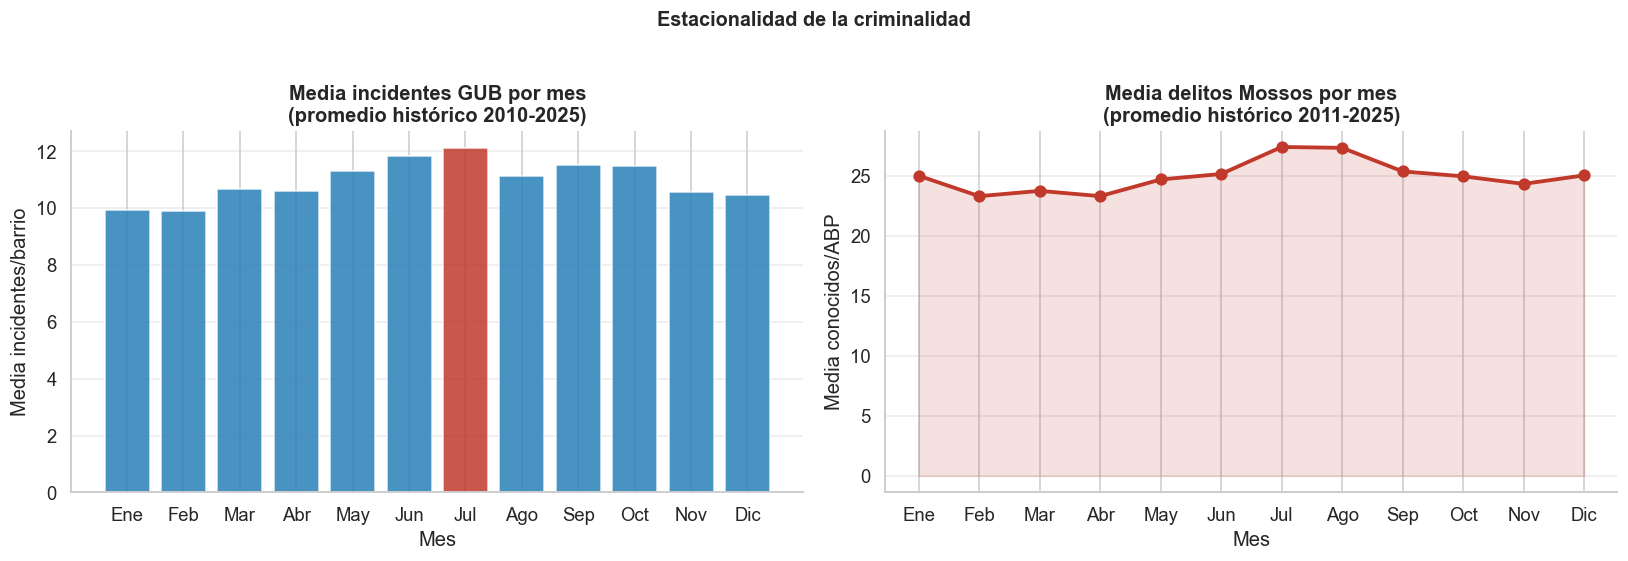

In [22]:
# Estacionalidad: media de incidentes/delitos por mes del año
gub_mes = fact_gub.merge(dim_tiempo[['id_tiempo','mes']], on='id_tiempo')
gub_mes = gub_mes[gub_mes['mes'].notna()].copy()
gub_mes['mes'] = gub_mes['mes'].astype(int)
estac_gub = gub_mes.groupby('mes')['num_incidents'].mean().reset_index()
estac_gub['nom_mes'] = estac_gub['mes'].apply(lambda m: MESES_ES[m-1])

mossos_mes = fact_mossos.merge(dim_tiempo[['id_tiempo','mes']], on='id_tiempo')
mossos_mes = mossos_mes[mossos_mes['mes'].notna()].copy()
mossos_mes['mes'] = mossos_mes['mes'].astype(int)
estac_mos = mossos_mes.groupby('mes')['coneguts'].mean().reset_index()
estac_mos['nom_mes'] = estac_mos['mes'].apply(lambda m: MESES_ES[m-1])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
_max_gub = estac_gub['num_incidents'].max()
cols_bar = [COL_CRIME if v==_max_gub else COL_GUB for v in estac_gub['num_incidents']]
ax.bar(estac_gub['nom_mes'], estac_gub['num_incidents'], color=cols_bar, alpha=0.85, zorder=2)
ax.set_title('Media incidentes GUB por mes\n(promedio histórico 2010-2025)', fontweight='bold')
ax.set_xlabel('Mes'); ax.set_ylabel('Media incidentes/barrio'); ax.grid(axis='y', alpha=0.4, zorder=1)

ax = axes[1]
ax.plot(estac_mos['nom_mes'], estac_mos['coneguts'],
        color=COL_CRIME, linewidth=2.5, marker='o', markersize=7, zorder=2)
ax.fill_between(range(len(estac_mos)), estac_mos['coneguts'], alpha=0.15, color=COL_CRIME)
ax.set_xticks(range(len(estac_mos))); ax.set_xticklabels(estac_mos['nom_mes'])
ax.set_title('Media delitos Mossos por mes\n(promedio histórico 2011-2025)', fontweight='bold')
ax.set_xlabel('Mes'); ax.set_ylabel('Media conocidos/ABP'); ax.grid(axis='y', alpha=0.4, zorder=1)

plt.suptitle('Estacionalidad de la criminalidad', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [23]:
# Tabla resumen de features para el modelo ML
features_ml = [
    {'Feature': 'id_territorio (barri/ABP)', 'Tabla': 'dim_territorio',
     'Granularidad': 'barrio (74) / ABP (62)', 'Años': '2010-2025',
     'Encoding': 'One-hot o target encoding', 'Notas': 'Variable espacial principal'},
    {'Feature': 'mes', 'Tabla': 'dim_tiempo',
     'Granularidad': 'mensual', 'Años': '2010-2025',
     'Encoding': 'Cíclico: sin/cos(2pi·mes/12)', 'Notas': 'Captura estacionalidad'},
    {'Feature': 'anyo', 'Tabla': 'dim_tiempo',
     'Granularidad': 'anual', 'Años': '2010-2025',
     'Encoding': 'Numeric', 'Notas': 'Tendencia temporal'},
    {'Feature': 'renta_tributaria_barri', 'Tabla': 'ctx_renta_barri',
     'Granularidad': 'barrio', 'Años': '2015-2023',
     'Encoding': 'Normalizado (z-score)', 'Notas': 'Join por id_territori'},
    {'Feature': 'pct_baja_edu', 'Tabla': 'ctx_socioeconomico',
     'Granularidad': 'barrio / distrito', 'Años': '2011-2023',
     'Encoding': 'Normalizado', 'Notas': 'indicador=nivell_educatiu'},
    {'Feature': 'paro_registrat', 'Tabla': 'ctx_socioeconomico',
     'Granularidad': 'Barcelona municipio', 'Años': '2005-2025',
     'Encoding': 'Normalizado', 'Notas': 'Solo nivel ciudad'},
    {'Feature': 'incidents_mes_anterior (lag-1)', 'Tabla': 'fact_incidentes_gub',
     'Granularidad': 'barrio x mes', 'Años': '2010-2025',
     'Encoding': 'Numeric', 'Notas': 'Feature autorregresiva principal'},
    {'Feature': 'incidents_anyo_anterior (lag-12)', 'Tabla': 'fact_incidentes_gub',
     'Granularidad': 'barrio x mes', 'Años': '2010-2025',
     'Encoding': 'Numeric', 'Notas': 'Captura ciclo anual'},
    {'Feature': 'centroide lat/lon', 'Tabla': 'geo_territorio',
     'Granularidad': 'barrio / ABP', 'Años': 'estático',
     'Encoding': 'Numeric', 'Notas': 'Para K-Means / modelos espaciales'},
]
df_feat = pd.DataFrame(features_ml).set_index('Feature')
display(df_feat.style.set_caption('Features para el modelo ML de predicción espacial de criminalidad')
        .set_table_styles([{'selector':'caption','props':[('font-size','13px'),('font-weight','bold'),('text-align','left')]}]))

print("\nVentana de entrenamiento recomendada: 2015-2022 (con datos de renta)")
print("Test set recomendado: 2023-2024")
print("Target: num_incidents / coneguts del mes siguiente (regresión) o alta/baja criminalidad (clasificación)")

,Tabla,Granularidad,Años,Encoding,Notas
Feature,,,,,
id_territorio (barri/ABP),dim_territorio,barrio (74) / ABP (62),2010-2025,One-hot o target encoding,Variable espacial principal
mes,dim_tiempo,mensual,2010-2025,Cíclico: sin/cos(2pi·mes/12),Captura estacionalidad
anyo,dim_tiempo,anual,2010-2025,Numeric,Tendencia temporal
renta_tributaria_barri,ctx_renta_barri,barrio,2015-2023,Normalizado (z-score),Join por id_territori
pct_baja_edu,ctx_socioeconomico,barrio / distrito,2011-2023,Normalizado,indicador=nivell_educatiu
paro_registrat,ctx_socioeconomico,Barcelona municipio,2005-2025,Normalizado,Solo nivel ciudad
incidents_mes_anterior (lag-1),fact_incidentes_gub,barrio x mes,2010-2025,Numeric,Feature autorregresiva principal
incidents_anyo_anterior (lag-12),fact_incidentes_gub,barrio x mes,2010-2025,Numeric,Captura ciclo anual
centroide lat/lon,geo_territorio,barrio / ABP,estático,Numeric,Para K-Means / modelos espaciales



Ventana de entrenamiento recomendada: 2015-2022 (con datos de renta)
Test set recomendado: 2023-2024
Target: num_incidents / coneguts del mes siguiente (regresión) o alta/baja criminalidad (clasificación)


<div style="background:#fef9e7;border-left:4px solid #f39c12;padding:15px 20px;border-radius:6px;margin:10px 0;">
<strong>Para el modelo ML:</strong><br>
Los <strong>lag features</strong> (mes anterior, mismo mes año anterior) serán los predictores más potentes. La <strong>renta por barrio</strong> y el <strong>mes codificado cíclicamente</strong> completan las features clave. Para delitos raros (homicidis, assassinats), agregar a nivel anual o districte para evitar sparsidad.
</div>

---
<div style="background:linear-gradient(135deg,#0d1117,#161b22);padding:40px;border-radius:16px;border-top:4px solid #e74c3c;margin-top:30px;">
  <h2 style="color:#fff;font-size:1.8em;margin-bottom:20px;">Conclusiones del EDA</h2>
  <div style="display:flex;flex-wrap:wrap;gap:20px;">
    <div style="background:rgba(231,76,60,0.1);border:1px solid #e74c3c;border-radius:8px;padding:20px;flex:1 1 45%;min-width:280px;box-sizing:border-box;">
      <h3 style="color:#e74c3c;margin-top:0;">Criminalidad</h3>
      <ul style="color:#c8d0e0;margin:0;">
        <li>Tasa per cápita <strong>estable</strong> en el periodo, sin tendencia significativa (confirmado con Mann-Kendall en el análisis estadístico), con un valle marcado en 2020 por el confinamiento</li>
        <li>El <strong>COVID-19</strong> (2020) marca una caída brusca y artificial</li>
        <li>Los robos dominan, pero los delitos sexuales crecen en proporción</li>
        <li>Alta concentración geográfica: top 10 zonas = mayoría de delitos</li>
      </ul>
    </div>
    <div style="background:rgba(142,68,173,0.1);border:1px solid #8e44ad;border-radius:8px;padding:20px;flex:1 1 45%;min-width:280px;box-sizing:border-box;">
      <h3 style="color:#8e44ad;margin-top:0;">Penitenciaria y sociedad</h3>
      <ul style="color:#c8d0e0;margin:0;">
        <li>Población reclusa <strong>estable o en descenso</strong> desde 2012</li>
        <li>Perfil: mayoría hombres, delitos contra el patrimonio y las personas</li>
        <li>Alta representación de nacionalidad extranjera respecto a la población</li>
      </ul>
    </div>
    <div style="background:rgba(39,174,96,0.1);border:1px solid #27ae60;border-radius:8px;padding:20px;flex:1 1 45%;min-width:280px;box-sizing:border-box;">
      <h3 style="color:#27ae60;margin-top:0;">Percepción de seguridad</h3>
      <ul style="color:#c8d0e0;margin:0;">
        <li>La percepción <strong>no siempre coincide</strong> con la estadística policial</li>
        <li>La <strong>cibervictimización</strong> crece mientras la física se estabiliza</li>
        <li>Más seguros en el <strong>barrio</strong> que en la <strong>ciudad</strong> en general</li>
      </ul>
    </div>
    <div style="background:rgba(41,128,185,0.1);border:1px solid #2980b9;border-radius:8px;padding:20px;flex:1 1 45%;min-width:280px;box-sizing:border-box;">
      <h3 style="color:#2980b9;margin-top:0;">Modelo ML</h3>
      <ul style="color:#c8d0e0;margin:0;">
        <li><strong>Lag features</strong> (t-1, t-12): predictores más potentes esperados</li>
        <li>Renta y educación correlacionan con incidentes en absoluto, pero el efecto se anula al normalizar per cápita (<strong>sesgo de exposición</strong>): ninguna predice criminalidad real por residente</li>
        <li>Estacionalidad clara: pico en <strong>verano</strong> (más actividad en la calle)</li>
        <li>Ventana óptima: <strong>2015-2024</strong> (con datos socioeconómicos)</li>
      </ul>
    </div>
  </div>
</div>
